## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import CubicSpline, PchipInterpolator, interp1d, UnivariateSpline
from sklearn.isotonic import IsotonicRegression

from typing import List, Tuple
from datetime import datetime
import io
import math

from IPython.display import display_html

## Data Model

In [2]:
class Data:
    
    tenor_buckets = np.array([0.0,7/365,30/365,60/365,0.25,0.5,0.75,1.0,1.5,2.0,3.0,5.0,7.0,10.0,20.0,30.0])
    

    def __init__(self, file_paths):
        self.file_paths = file_paths
        self.load_bills_bonds_deposits(file_paths)
        self.full_grid = np.linspace(0.01, 20.0, 100)
        self.short_grid = np.linspace(0.01, 2.0, 20)
        self.tenor_buckets = np.array([0.0,7/365,30/365,60/365,0.25,0.5,0.75,1.0,1.5,2.0,3.0,5.0,7.0,10.0,20.0,30.0])
        
    def __str__(self):
        # to do
        return 'This is a Data model.'
    
    
    
    def display_side_by_side(self, *dfs):
        html_str = ''
        for df in dfs:
            html_str += df.to_html(index=False) + "&nbsp;&nbsp;"
        display_html(html_str, raw=True)
                
        return
    
        
    def load_bills_bonds_deposits(self, file_paths):
        tbills_df = self.load_t_bills(file_paths['T_Bills'])
        bonds_df, bonds_obs_date = self.load_bonds(file_paths['Bonds'])
        deposits_df = self.load_mrkt_deposits(file_paths['Market_Deposits'])
        
        dfs = [tbills_df, bonds_df, deposits_df]
        
        self.ensure_data_monotonicity(dfs) 
        
        print('\n--- Data Loaded Successfully ---\n')
        
        return self
    
    
    def ensure_data_monotonicity(self, dfs):
        
        df = dfs[0].copy()        
        violations = self.find_monotonic_violations(df)
        if not violations.empty:
            print("Violations:\n", violations)
        tbill_df = self.enforce_monotonic_isotonic(df)
        print("\n::Treasury BIlls Data::\n")
        self.display_side_by_side(tbill_df)
        self.tbills_df = tbill_df
        
        
        df = dfs[1].copy() 
        violations = self.find_monotonic_violations(df)
        if not violations.empty:
            print("Violations:\n", violations)
        bonds_df = self.enforce_monotonic_isotonic(df)
        print("\n::Private Placements Data::\n")
        self.display_side_by_side(bonds_df)
        self.bonds_df = bonds_df
        
        
        df = dfs[2].copy() 
        violations = self.find_monotonic_violations(df)
        if not violations.empty:
            print("Violations:\n", violations)
        deposits_df = self.enforce_monotonic_isotonic(df)
        print("\n::Market Deposits Data::\n")
        self.display_side_by_side(deposits_df)
        self.deposits_df = deposits_df
        
        
        return
        
     
    
    def load_t_bills(self, file_path):
        df = pd.read_csv(file_path)

        numeric_cols = ['Average Discount Rate', 'Average Competitive Yield']
        for col in numeric_cols:
            df[col] = df[col].astype(str).str.replace('SZL','').str.replace('%','')
            df[col] = pd.to_numeric(df[col].str.strip(), errors='coerce')

        df['Settlement Date'] = pd.to_datetime(df['Settlement Date'], errors='coerce', dayfirst=True)
        df['Maturity Date'] = pd.to_datetime(df['Maturity Date'], errors='coerce', dayfirst=True)
        df['Tenor'] = (df['Maturity Date'] - df['Settlement Date']).dt.days / 365.25
        df['Yield'] = df['Average Competitive Yield'] / 100.0

        tbill_df = (
            df[['Tenor','Yield']]
            .groupby('Tenor', as_index=False)
            .agg({'Yield': 'mean'})
            .sort_values('Tenor')
            .reset_index(drop=True)
        )
                

        return tbill_df
    
    
    
    def load_bonds(self, file_path):
        df = pd.read_csv(file_path, low_memory=False)

        df['Maturity date'] = pd.to_datetime(df['Maturity date'], format='%d-%b-%y')
        df.set_index('Maturity date', inplace=True)
        df.bfill(inplace=True)
        df.columns = [col.split('.')[0] if col != 'Maturity date' else col for col in df.columns]

        obs_date = df.index[-1]
        maturity_dates = [pd.to_datetime(col, format='%d-%b-%y') for col in df.columns]
        tenors = np.array([(maturity_date - obs_date).days / 365.25 for maturity_date in maturity_dates])
        yields = df.iloc[-1].values

        bonds_df = pd.DataFrame(maturity_dates, columns=['Maturity Date'])
        bonds_df['Tenor'] = tenors
        bonds_df['Yield'] = yields / 100.0

        bonds_df = (
            bonds_df[['Tenor','Yield']]
            .groupby('Tenor', as_index=False)
            .agg({'Yield': 'mean'})
            .sort_values('Tenor')
            .reset_index(drop=True)
        )

        return bonds_df, obs_date


        
    def load_mrkt_deposits(self, file_path):
        """
        Load and preprocess deposit‐rate data.
        Expects a CSV with columns like:
          tenor, yield (nedbank), yield (fnb)
        Returns a DataFrame with numeric Tenor (yrs) and chosen Yield (%).
        """
        df = pd.read_csv(file_path)
        df = df.rename(columns={
            df.columns[0]: 'Tenor',
            df.columns[1]: 'Nedbank',
            df.columns[2]: 'FNB'
        })

        df['Tenor'] = (
            df['Tenor']
              .astype(str)
              .str.strip()
              .str.replace(r"\s+", "", regex=True)
        )
        df['Tenor'] = pd.to_numeric(df['Tenor'], errors='coerce')

        for col in ['Nedbank', 'FNB']:
            df[col] = (
                df[col]
                  .astype(str)
                  .str.strip()
                  .str.replace(r"[^\d\.]+", "", regex=True)
            )
            df[col] = pd.to_numeric(df[col], errors='coerce')


        df['Yield'] = df['Nedbank'].fillna(df['FNB'])
        df = df.dropna(subset=['Tenor', 'Yield'])

        df['Yield'] = df['Yield'] / 100.0


        df = df.sort_values('Tenor').reset_index(drop=True)
        df.to_excel('export/deposits.xlsx', index=False)

        return df[['Tenor', 'Yield']]
    
    
    
    def percent_to_decimal(self, base_bkt):
        med = base_bkt['Yield'].median()
        if med > 1.0:
            print(f"[base_bkt] detected pct‑points (median={med:.3f}), converting to decimal.")
            base_bkt['Yield'] = base_bkt['Yield'] / 100.0
        else:
            print(f"[base_bkt] detected decimal yields (median={med:.3f}), no conversion.")


        return base_bkt

    
    
    def assign_bucket(self, x, buckets=tenor_buckets):
        """Find the nearest bucket for tenor x."""
        idx = np.abs(buckets - x).argmin()
        return buckets[idx]

    def bucket_and_merge(self, df, tenor_col='Tenor', yield_col='Yield', how='mean'):
        """
        1. Assign each tenor to nearest bucket.
        2. Aggregate yields in each bucket.
        3. Compute discrete discount factor for each bucket
        4. Return bucket summary (Tenor, Yield).
        """
        df = df.copy()
        df['Bucket'] = df[tenor_col].apply(self.assign_bucket)

        agg = (
            df
            .groupby('Bucket', as_index=False)
            .agg({ yield_col: how })
            .rename(columns={ yield_col: 'Yield' })
        )
        # discrete DF for each bucket
        agg['DiscountFactor'] = 1.0 / (1.0 + agg['Yield'] * agg['Bucket'])

        agg = agg.sort_values('Bucket').reset_index(drop=True)
        agg.rename(columns={'Bucket':'Tenor'}, inplace=True)
        return agg



    def find_monotonic_violations(self, our_data: pd.DataFrame, yield_col = 'Yield') -> pd.DataFrame:

        df = our_data.copy()
        df.sort_values('Tenor').reset_index(drop=True)
        df['Diff'] = df[yield_col].diff()
        violations = df[df['Diff'] < 0]

        return violations[['Tenor', yield_col, 'Diff']]


    def enforce_monotonic_isotonic(self, df: pd.DataFrame, yield_col='Yield') -> pd.DataFrame:
        """
        Uses isotonic regression to find best-fitting non decreasing sequence of yields
        """
        df_iso = df.sort_values('Tenor').reset_index(drop=True)
        ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
        y_iso = ir.fit_transform(df_iso['Tenor'], df_iso[yield_col])
        df_iso[f'{yield_col}_'] = y_iso
        df = df_iso[['Tenor', f'{yield_col}_']].rename(columns={ 'Yield_': 'Yield' })

        return df
    
    
    
    def prep_discount_rate_data(self):
        deposit_rates_df = self.deposits_df
        tbill_df = self.tbills_df
        
        deposit_bkt = self.bucket_and_merge(deposit_rates_df, tenor_col='Tenor', yield_col='Yield')
        tbill_bkt = self.bucket_and_merge(tbill_df, tenor_col='Tenor', yield_col='Yield')
        
        deposit_bkt.to_excel('export/deposit_bkt.xlsx', index=False)
        tbill_bkt.to_excel('export/tbills_bkt.xlsx', index=False)
        
        print("\n::Bucketed Market Deposits Data::\n")
        self.display_side_by_side(deposit_bkt)
        print("\n::Bucketed Treasury BIlls Data::\n")
        self.display_side_by_side(tbill_bkt)
        
        self.deposit_bkt = deposit_bkt
        self.tbill_bkt = tbill_bkt
        
        
        tbill_obs = tbill_bkt[tbill_bkt['Tenor'] <= 2.0]
        deposit_obs = deposit_bkt[deposit_bkt['Tenor'] <= 2.0]
        
        
        output = {
            'tbill_obs': tbill_obs,
            'deposit_obs': deposit_obs
        }
        
        return output
    
    
    def prepare_base_fit_data(self, mono=None):
        bond_df = self.bonds_df
        tbill_df = self.tbills_df
    
        tbills_for_base = tbill_df[tbill_df['Tenor'] <= 1.0]
        bonds_for_base  = bond_df[(bond_df['Tenor'] >= 1.0) & (bond_df['Tenor'] <= 10.0)]

        tenors_base = np.concatenate([
            tbills_for_base['Tenor'].to_numpy(),
            bonds_for_base['Tenor'].to_numpy()
        ])
        yields_base = np.concatenate([
            tbills_for_base['Yield'].to_numpy(),
            bonds_for_base['Yield'].to_numpy()
        ])


        base_df = pd.DataFrame({
            'Tenor': tenors_base,
            'Yield': yields_base
        })
        base_df = base_df.sort_values('Tenor').reset_index(drop=True)
        self.base_df = base_df

        base_bkt = self.bucket_and_merge(base_df, tenor_col='Tenor', yield_col='Yield')
        base_bkt = self.percent_to_decimal(base_bkt)

        if mono:
            violations = self.find_monotonic_violations(base_bkt)
            if not violations.empty:
                print("Violations:\n", violations)

            base_mono = self.enforce_monotonic_isotonic(base_bkt)
            base_mono.to_excel('export/base_mono_df.xlsx', index=False)

            return base_mono

        base_bkt.to_excel('export/base_bkt_df.xlsx', index=False)
        self.base_bkt = base_bkt

        return base_bkt
    

## NS Fit Model

---

**Nelson–Siegel (4‑parameter)**

**Spot Yield Function**

$$
y_{\text{NS}}(t) \;=\;
\beta_{0}
\;+\;\beta_{1}\,\underbrace{\Bigl(\frac{1 - e^{-t/\tau}}{t/\tau}\Bigr)}_{\displaystyle L(t;\tau)}
\;+\;\beta_{2}\,\underbrace{\Bigl(\frac{1 - e^{-t/\tau}}{t/\tau} \;-\; e^{-t/\tau}\Bigr)}_{\displaystyle C(t;\tau)}
$$

* **Parameters**

  * $\beta_{0}$: long‑run level (as $t\to\infty$)
  * $\beta_{1}$: short‑term slope (drives $y(0)\approx\beta_{0}+\beta_{1}$)
  * $\beta_{2}$: medium‑term curvature (hump size)
  * $\tau$: decay factor (hump location)


**Instantaneous Forward Rate**

If you need the forward curve $f_{\text{NS}}(t)$, it follows by differentiation:

$$
f_{\text{NS}}(t)
\;=\;\frac{d}{dt}\Bigl[t\,y_{\text{NS}}(t)\Bigr]
\;=\;\beta_{0}
\;+\;\beta_{1}\,e^{-t/\tau}
\;+\;\beta_{2}\,\frac{t}{\tau}\,e^{-t/\tau}
$$

---

In [5]:
class NelsonSiegelFit:
    
    
    def __init__(self, curve):
        self.tenors = curve.base_data["Tenor"]
        self.yields = curve.base_data["Yield"]
        self.grid = curve.full_grid
        self.helper = Helper(self.grid)
        
        
        
    def run_fit(self):
        self.fit_results = self.nelson_siegel_function_fit()
        self.curve = self.fit_results['curve_no_shift']
        self.final_params = self.fit_results['final_params']
        self.sse = self.fit_results['final_sse']
        self.rmse = self.fit_results['final_rmse']
        
        return self.fit_results
        
        
     
    def nelson_siegel_function_fit(self, init=None, bounds=None, constraints=None):
    
        init_ns = [self.yields.iloc[-1],
               self.yields.iloc[0] - self.yields.iloc[-1],
               0.0, 
               1.0]


        ns_params, sse, rmse = self.fit_ns(
            tenors=self.tenors,
            yields=self.yields,
            weights=None,
            bounds=None,
            init_center=init_ns,
            starts=30,
            constraints=None,
            visualize=True
        )


        curve = self.ns_curve(self.grid, ns_params)

        results = {
            'curve_no_shift': curve,
            'final_params': ns_params,
            'final_sse': sse,
            'final_rmse': rmse,
            'final_grid': self.grid,
            'final_tenors': self.tenors,
            'final_yields': self.yields
        }
        
        self.helper.visualize_fit(results)
        

        return results

    
    
    def ns_yield(self, t, beta0, beta1, beta2, tau):
        if t <= 0:
            return beta0 + beta1
        x = t / tau
        term1 = (1 - np.exp(-x)) / x
        term2 = term1 - np.exp(-x)
        return beta0 + beta1*term1 + beta2*term2    # 0.01 *

    def ns_curve(self, tenors, params):
        return np.array([self.ns_yield(t, *params) for t in tenors])

    def ns_cost(self, params, tenors, yields_obs, weights=None):
        y_pred = self.ns_curve(tenors, params)
        w = weights if weights is not None else np.ones_like(yields_obs)
        return np.sum(w * (yields_obs - y_pred)**2)

    def fit_ns(self, tenors, yields, weights=None, bounds=None,
               init_center=None, starts=10,
               constraints=None,
               visualize=False, tol=1e-6):
        """
        Fit NS with multiple unique random starts and optional constraints.
        `constraints` should be a list of dicts in {'type':'eq'|'ineq','fun':callable} form.
        """
        def ns_cost_wrap(p):
            return self.ns_cost(p, tenors, yields, weights)

        def gen_start(center):
            if center is None:
                return [yields[-1], yields[0]-yields[-1], 0.0, 1.0]
            return [param*np.random.uniform(0.8,1.2) for param in center]

        progress_interval=10

        inits = []
        while len(inits) < starts:
            init = tuple(gen_start(init_center))
            if not any(np.allclose(init, prev, atol=tol) for prev in inits):
                inits.append(init)

        best_sse, best_params = np.inf, None
        for idx, init in enumerate(inits, start=1):
            res = minimize(
                ns_cost_wrap,
                x0=init,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints or []
            )
            if res.success and res.fun < best_sse:
                best_sse, best_params = res.fun, res.x

            if idx % progress_interval == 0 or idx == starts:
                print(f"[{idx}/{starts}] starts, best SSE = {best_sse:.4f}")

        if best_params is None:
            raise RuntimeError("NS fitting failed to converge")

        rmse = np.sqrt(best_sse / len(yields))

        if visualize:
            y_fit    = self.ns_curve(tenors, best_params)
            residual = yields - y_fit

            plt.figure(figsize=(12,5))
            plt.scatter(tenors, yields, label='Obs')
            plt.plot(tenors, y_fit, label=f'Fit (RMSE={rmse:.3f}%)')
            plt.legend(); plt.grid(); plt.title("NS Fit"); plt.xlabel("Tenor"); plt.ylabel("Yield")
            plt.show()

            plt.figure(figsize=(12,5))
            plt.stem(tenors, residual, basefmt=" ")
            plt.title("Residuals"); plt.xlabel("Tenor"); plt.ylabel("Obs–Fit")
            plt.grid(); plt.show()

        return best_params, best_sse, rmse
    

## Main

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
# tbills_data = load_tbills('/content/drive/MyDrive/nedbank/FTP/treasury_bills_data.csv')
# bonds_data, obs_date = load_bonds('/content/drive/MyDrive/nedbank/FTP/bond_yields_data.csv')
# jibar_data = load_jibar('/content/drive/MyDrive/nedbank/FTP/jibar_curve_data.csv')
# deposit_rates_data = load_deposits_comp('/content/drive/MyDrive/nedbank/FTP/deposit_rates_compare.csv')

---

**1.	Anchor to Short-Term Funding Basis**
    
The 3 month deposit–T-bill spread
$$
\Delta_{3m} \;=\; r_{\rm dep}(0.25) \;-\; r_{\rm tbill}(0.25)
$$

is the market’s liquidity and credit premium for that horizon.  By shifting the entire FTP base curve down by this amount, we ensure that at t=0.25 our internal curve exactly matches the observable market basis.

---

In [8]:
file_paths = {
    'T_Bills': 'input/treasury_bills_data.csv',
    'Bonds': 'input/bond_yields_data.csv',
    'Market_Deposits': 'input/deposit_rates_compare.csv'
}

In [9]:
data_obj = Data(file_paths)

Violations:
        Tenor     Yield      Diff
1   0.246407  0.074157 -0.007118
2   0.249144  0.071992 -0.002165
6   0.498289  0.077735 -0.007765
10  0.744695  0.094980 -0.006120
11  0.747433  0.081229 -0.013751
12  0.750171  0.067244 -0.013984
14  0.996578  0.084573 -0.006377

::Treasury BIlls Data::



Tenor,Yield
0.240931,0.075479
0.246407,0.075479
0.249144,0.075479
0.251882,0.075479
0.490075,0.081300
0.495551,0.081617
0.498289,0.081617
0.501027,0.084312
0.739220,0.086851
0.741958,0.086851


Violations:
        Tenor    Yield     Diff
3   0.284736  0.10235 -0.00010
6   1.029432  0.10445 -0.00078
11  2.280630  0.10799 -0.00370
21  4.616016  0.11675 -0.00205
22  4.695414  0.11486 -0.00189
24  5.286790  0.11553 -0.00156
26  6.609172  0.11718 -0.00322
28  7.279945  0.11872 -0.00503

::Private Placements Data::



Tenor,Yield
-0.306639,0.099200
-0.134155,0.099750
0.279261,0.102400
0.284736,0.102400
0.698152,0.103570
0.944559,0.104840
1.029432,0.104840
1.286790,0.105150
1.694730,0.106240
1.949350,0.107170



::Market Deposits Data::



Tenor,Yield
0.08,0.0310
0.16,0.0345
0.24,0.0355
0.48,0.0385
0.96,0.0540
1.93,0.0695
2.89,0.0720
4.82,0.0745



--- Data Loaded Successfully ---



---

**Curve Shape Preservation**

A parallel shift
$$
y_{\text{new}}(t)
= y_{\text{orig}}(t)\;-\;\Delta_{3m}
$$

leaves the NS/NSS-implied shape (humps, slopes, curvature) intact, while correcting the level to be consistent with short-term funding reality.

**Simplicity & Auditability**

* Stakeholders intuitively grasp “we subtracted the 3 M basis points.”
* The approach requires no re-fitting or complex re-bootstrapping—just one number pulled from live market data.
    
---

In [10]:
base_term = Curve(data_obj)


--- Curve Model Created Successfully. ---



$$
\boxed{
\ell_{\rm asset}(t)\;=\;L(t_P,t_V) \;=\; r_{\text{price of money}}(t_P)\;-\;r_{\text{cost of asset}}(t_C)
}
$$

$$
\boxed{
\ell_{\rm liability}(t)\;=\;L(t_P,t_C) \;=\; r_{\text{price of money}}(t_P)\;-\;r_{\text{value of money}}(t_V)
}
$$




$$
L = r_{\text{price}} - r_{\text{value/cost}}
$$


- Positive $L$ means the market price of money is higher than the value/cost of money. ***→ liquidity is costly to obtain***

- Negative $L$ means the market price is lower than your internal value/cost point. ***→ liquidity is beneficial or cheap relative to market***

In [11]:
# placeholder values
meta = {
    'prime_rate': 10.25,
    'call_rate': 5.50,
    'repo_rate': 6.75,
    'reg_cap': 12.0
}


::Bucketed Market Deposits Data::



Tenor,Yield,DiscountFactor
0.082192,0.0310,0.997459
0.164384,0.0345,0.994361
0.250000,0.0355,0.991203
0.500000,0.0385,0.981114
1.000000,0.0540,0.948767
2.000000,0.0695,0.877963
3.000000,0.0720,0.822368
5.000000,0.0745,0.728597



::Bucketed Treasury BIlls Data::



Tenor,Yield,DiscountFactor
0.25,0.075479,0.981480
0.50,0.082212,0.960517
0.75,0.086851,0.938846
1.00,0.088924,0.918338


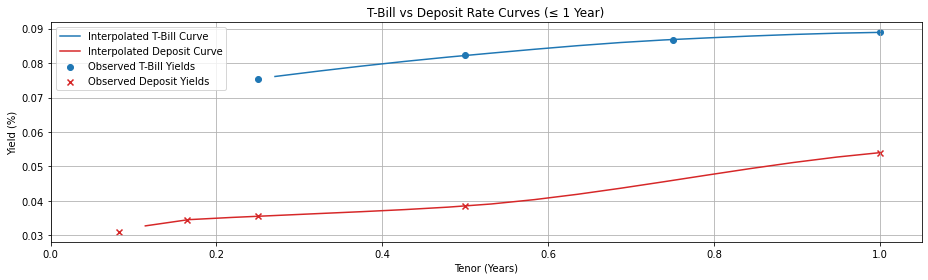

[Deposit - T Bill]  @ 3 M    (0.25 yr) = -4.00% (-399.79 bps)
[Deposit - T Bill]  @ 6 M    (0.50 yr) = -4.37% (-437.12 bps)
[Deposit - T Bill]  @ 9 M    (0.75 yr) = -4.09% (-409.11 bps)
[Deposit - T Bill]  @ 12 M   (1.00 yr) = -3.49% (-349.24 bps)
[base_bkt] detected decimal yields (median=0.107), no conversion.
[10/30] starts, best SSE = 0.0000
[20/30] starts, best SSE = 0.0000
[30/30] starts, best SSE = 0.0000


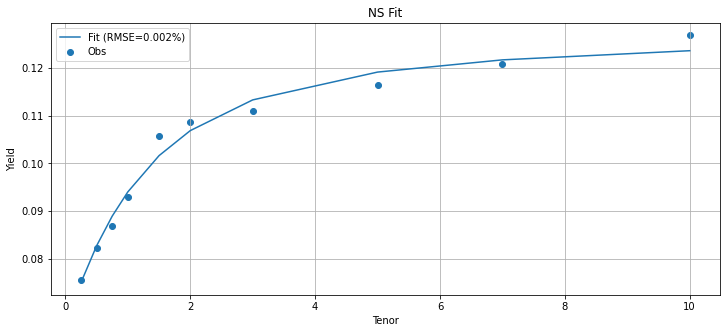

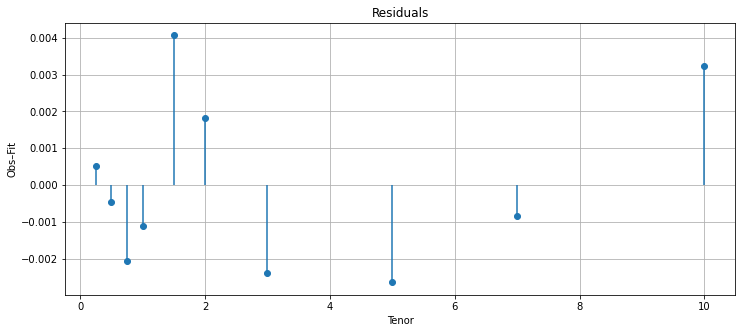


=== Asset Base NS Parameters ===
β₀   = 12.8186%   (long-term level)
β₁   = -0.0628    (short-term slope)
β₂   = 0.0107    (mid-curve curvature)
τ    = 0.8612 yrs (hump decay)
SSE  = 0.0000, RMSE = 0.0022%



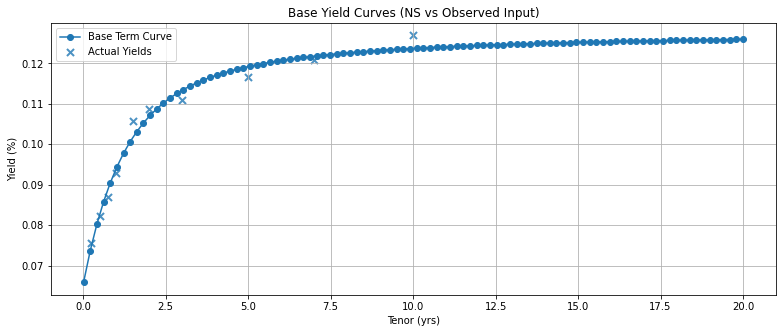

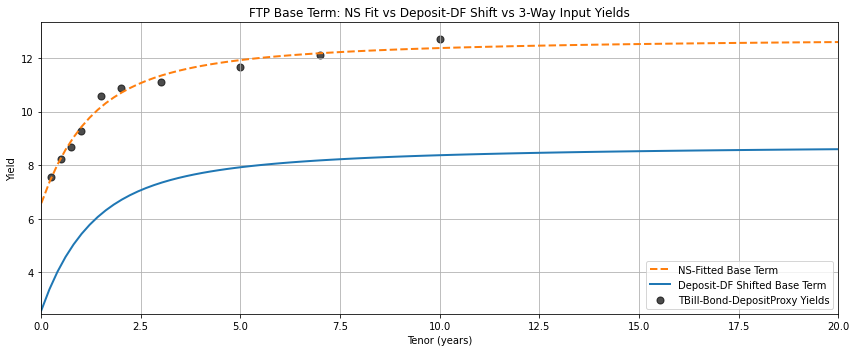

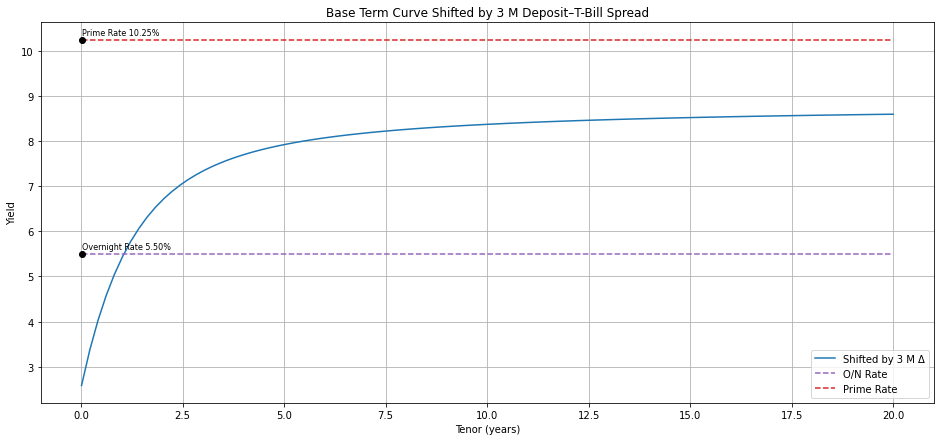

FTP(0.00 yr) = 2.5841%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(0.02 yr) = 2.6196%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(0.08 yr) = 2.8636%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(0.16 yr) = 3.1819%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(0.25 yr) = 3.4897%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(0.50 yr) = 4.2580%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(0.75 yr) = 4.8855%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(1.00 yr) = 5.4003%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(1.50 yr) = 6.1609%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(2.00 yr) = 6.6899%  ✔ within limits. prime rate 10.25% & regulation cap 12.0% not exceeded.
FTP(3.00 yr) = 7.3364%  ✔ within limits.

In [12]:
base_term.run_ftp_model(meta)

***NOW WE HAVE:***

$$
\boxed{
\;y_{\rm BASE}(t) =
\underbrace{\;y_{\rm NS}(t)}_{\text{T Bill + Bond NS Fitted}}
- \underbrace{\;y_{\rm adj}(t)}_{\text{3m Implied Discount Factor}}
}
$$



$$
\boxed{
\ell_{\rm asset}(t)\;=\;L(t_P,t_V) \;=\; r_{\text{price of money}}(t_P)\;-\;r_{\text{cost of asset}}(t_C)
}
$$

$$
\boxed{
\ell_{\rm liability}(t)\;=\;L(t_P,t_C) \;=\; r_{\text{price of money}}(t_P)\;-\;r_{\text{value of money}}(t_V)
}
$$